# Araç Modeli Tanıma — YOLOv8 Instance Segmentation
**Deney 1:** Tam Fine-tune | **Deney 2:** Backbone Frozen

## Hücre 1 — Kurulum

In [1]:
!pip install ultralytics kagglehub pyyaml --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00


## Hücre 2 — İmportlar

In [2]:
import os, shutil, gc, random
import numpy as np
import kagglehub
import yaml
import torch
from collections import Counter
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Hücre 3 — Sabitler & Klasör Yapısı

In [3]:
TARGET_CLASS_COUNT = 30   # Colab free için 30 sınıf
MAX_RESIM          = 120  # Sınıf başı max görüntü
CONF_THRESHOLD     = 0.70
IMGSZ              = 416  # 640 yerine 416 → bellek tasarrufu
EPOCHS             = 20   # Colab free için 20 epoch
BATCH              = 8    # Colab free GPU belleği için

base_dir = "/content/adas_model_projesi"
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

for split in ['train', 'valid', 'test']:
    os.makedirs(f"{base_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{base_dir}/{split}/labels", exist_ok=True)

print("Klasör yapısı oluşturuldu.")

Klasör yapısı oluşturuldu.


## Hücre 4 — Veri Seti İndir & Sınıfları Belirle

In [4]:
path = kagglehub.dataset_download("prondeau/the-car-connection-picture-dataset")
print(f"Veri seti yolu: {path}")

model_names = []
all_files   = []

for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith('.jpg'):
            all_files.append(os.path.join(root, file))
            parts = file.split('_')
            if len(parts) >= 2:
                model_names.append(f"{parts[0]}_{parts[1]}")

top_models = [name for name, count in Counter(model_names).most_common(TARGET_CLASS_COUNT)]
class_map  = {name: i for i, name in enumerate(top_models)}

print(f"Toplam JPG        : {len(all_files)}")
print(f"Seçilen sınıf sayısı: {len(top_models)}")
print(f"İlk 5 sınıf       : {top_models[:5]}")

100%|██████████| 682M/682M [00:05<00:00, 135MB/s]

Extracting files...


Veri seti yolu: /root/.cache/kagglehub/datasets/prondeau/the-car-connection-picture-dataset/versions/1
Toplam JPG        : 64467
Seçilen sınıf sayısı: 30
İlk 5 sınıf       : ['MINI_Cooper', 'Ford_Ranger', 'Ford_F-150', 'Honda_Civic', 'Chevrolet_Colorado']


## Hücre 5 — Otomatik Etiketleme
> YOLOv8m-seg ile arabaları tespit edip segmentasyon maskesi oluşturur. Colab free'de ~20-30 dk sürebilir.

In [5]:
labeler  = YOLO('yolov8m-seg.pt')
counters = {name: 0 for name in top_models}
processed_count = 0

random.shuffle(all_files)  # Karıştır, çeşitlilik artsın

for file_path in all_files:
    fname = os.path.basename(file_path)
    parts = fname.split('_')
    if len(parts) < 2:
        continue
    car_name = f"{parts[0]}_{parts[1]}"

    if car_name not in class_map:
        continue
    if counters[car_name] >= MAX_RESIM:
        continue

    results = labeler.predict(file_path, classes=[2], verbose=False, conf=CONF_THRESHOLD)
    if not results[0].masks:
        continue

    # %70 train / %15 valid / %15 test
    r = random.random()
    if   r < 0.70: split = 'train'
    elif r < 0.85: split = 'valid'
    else:          split = 'test'

    idx      = counters[car_name]
    img_name = f"{car_name}_{idx}"

    shutil.copy(file_path, f"{base_dir}/{split}/images/{img_name}.jpg")

    with open(f"{base_dir}/{split}/labels/{img_name}.txt", 'w') as f:
        for mask in results[0].masks.xyn:
            coords = " ".join(f"{x:.6f}" for x in mask.flatten())
            f.write(f"{class_map[car_name]} {coords}\n")

    counters[car_name] += 1
    processed_count    += 1

    if processed_count % 100 == 0:
        print(f"  {processed_count} resim işlendi...")

del labeler
gc.collect()
torch.cuda.empty_cache()

train_count = len(os.listdir(f"{base_dir}/train/images"))
valid_count = len(os.listdir(f"{base_dir}/valid/images"))
test_count  = len(os.listdir(f"{base_dir}/test/images"))

print(f"\nEtiketleme tamamlandı.")
print(f"  Train : {train_count}")
print(f"  Valid : {valid_count}")
print(f"  Test  : {test_count}")
print(f"  Toplam: {processed_count}")

  100 resim işlendi...
  200 resim işlendi...
  300 resim işlendi...
  400 resim işlendi...
  500 resim işlendi...
  600 resim işlendi...
  700 resim işlendi...
  800 resim işlendi...
  900 resim işlendi...
  1000 resim işlendi...
  1100 resim işlendi...
  1200 resim işlendi...
  1300 resim işlendi...
  1400 resim işlendi...
  1500 resim işlendi...
  1600 resim işlendi...
  1700 resim işlendi...
  1800 resim işlendi...
  1900 resim işlendi...
  2000 resim işlendi...
  2100 resim işlendi...
  2200 resim işlendi...
  2300 resim işlendi...
  2400 resim işlendi...
  2500 resim işlendi...

Etiketleme tamamlandı.
  Train : 1742
  Valid : 392
  Test  : 396
  Toplam: 2530


## Hücre 6 — data.yaml Oluştur

In [6]:
data_yaml = {
    'path'  : base_dir,
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : len(class_map),
    'names' : [n.replace('_', ' ') for n in top_models]
}

with open(f"{base_dir}/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f, allow_unicode=True)

print("data.yaml oluşturuldu:")
print(f"  Sınıf sayısı : {len(class_map)}")
print(f"  Sınıflar     : {data_yaml['names'][:5]} ...")

data.yaml oluşturuldu:
  Sınıf sayısı : 30
  Sınıflar     : ['MINI Cooper', 'Ford Ranger', 'Ford F-150', 'Honda Civic', 'Chevrolet Colorado'] ...


## Hücre 7 — Deney 1: YOLOv8m-seg Tam Fine-tune
> Tüm katmanlar eğitiliyor (backbone dahil).

In [7]:
print("=" * 50)
print("DENEY 1: YOLOv8m-seg — Tam Fine-tune")
print("=" * 50)

model_ft = YOLO('yolov8m-seg.pt')

model_ft.train(
    data         = f"{base_dir}/data.yaml",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    patience     = 7,
    device       = 0 if torch.cuda.is_available() else 'cpu',
    project      = base_dir,
    name         = 'deney1_fulltune',
    exist_ok     = True,
    hsv_h        = 0.015,
    hsv_s        = 0.5,
    hsv_v        = 0.3,
    fliplr       = 0.5,
    mosaic       = 0.5,
    mixup        = 0.0,
    freeze       = None,   # Hiçbir katman dondurulmaz
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    verbose      = True,
)

del model_ft
gc.collect()
torch.cuda.empty_cache()
print("Deney 1 tamamlandı.")

DENEY 1: YOLOv8m-seg — Tam Fine-tune
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/adas_model_projesi/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=deney1_fulltune, nbs=64, nms=False, opset=None, optimize=

## Hücre 8 — Deney 2: YOLOv8m-seg Backbone Frozen
> İlk 10 katman (backbone) dondurulur. Sadece detection/segmentation head eğitilir.

In [8]:
print("=" * 50)
print("DENEY 2: YOLOv8m-seg — Backbone Frozen")
print("=" * 50)

model_fr = YOLO('yolov8m-seg.pt')

model_fr.train(
    data         = f"{base_dir}/data.yaml",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    patience     = 7,
    device       = 0 if torch.cuda.is_available() else 'cpu',
    project      = base_dir,
    name         = 'deney2_frozen',
    exist_ok     = True,
    hsv_h        = 0.015,
    hsv_s        = 0.5,
    hsv_v        = 0.3,
    fliplr       = 0.5,
    mosaic       = 0.5,
    mixup        = 0.0,
    freeze       = 10,     # İlk 10 katman (backbone) dondurulur
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    verbose      = True,
)

del model_fr
gc.collect()
torch.cuda.empty_cache()
print("Deney 2 tamamlandı.")

DENEY 2: YOLOv8m-seg — Backbone Frozen
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/adas_model_projesi/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=deney2_frozen, nbs=64, nms=False, opset=None, optimize=Fa

## Hücre 9 — Karşılaştırma (Test Seti)
> PDF raporunda kullanılacak metrikler ve grafikler.

Deney 1 test değerlendirmesi...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,239,754 parameters, 0 gradients, 104.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2.7±3.0 MB/s, size: 12.7 KB)
val: Scanning /content/adas_model_projesi/test/labels... 396 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 396/396 433.6it/s 0.9s
val: New cache created: /content/adas_model_projesi/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 7.1it/s 7.1s
                   all        396        418      0.619      0.539      0.548      0.542      0.619      0.539      0.548      0.541
Speed: 0.6ms preprocess, 11.3ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/segment/val
Deney 2 test değerlendirmesi...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0

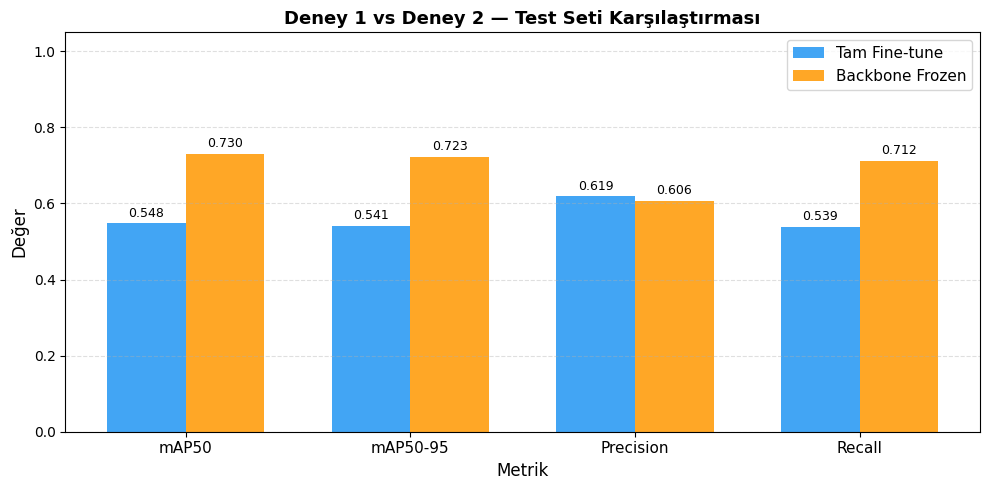

Grafik 1 kaydedildi.


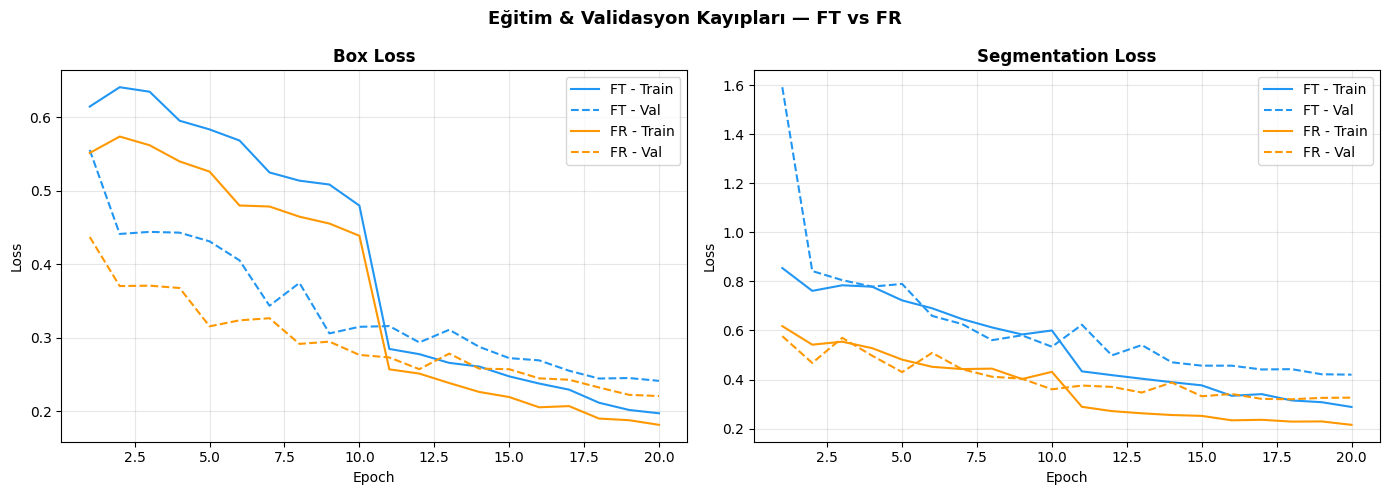

Grafik 2 kaydedildi.


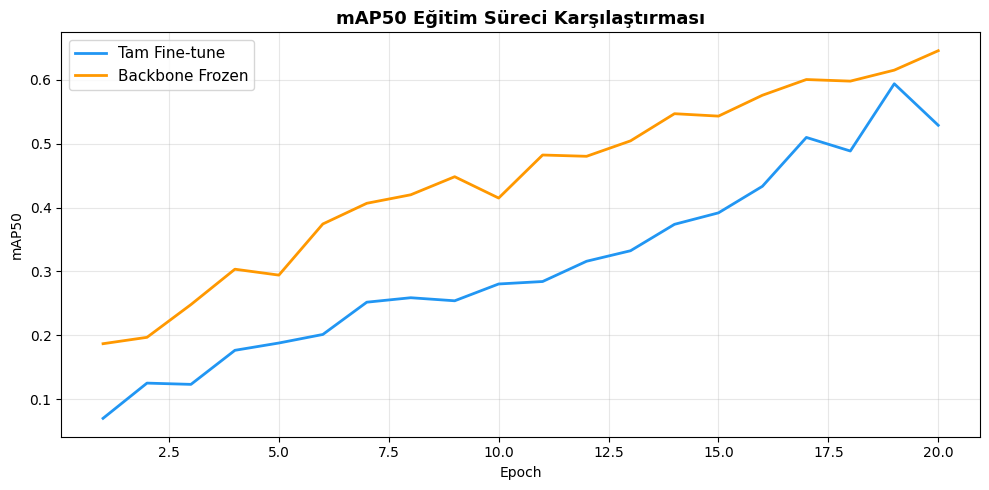

Grafik 3 kaydedildi.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import json

device = 0 if torch.cuda.is_available() else 'cpu'

best1 = f"{base_dir}/deney1_fulltune/weights/best.pt"
best2 = f"{base_dir}/deney2_frozen/weights/best.pt"

model1 = YOLO(best1)
model2 = YOLO(best2)

print("Deney 1 test değerlendirmesi...")
m1 = model1.val(data=f"{base_dir}/data.yaml", split='test',
                imgsz=IMGSZ, batch=BATCH, device=device, verbose=False)

print("Deney 2 test değerlendirmesi...")
m2 = model2.val(data=f"{base_dir}/data.yaml", split='test',
                imgsz=IMGSZ, batch=BATCH, device=device, verbose=False)

# ── Metrikleri topla ──────────────────────────────────────────
results = {
    "Tam Fine-tune": {
        "mAP50"    : round(float(m1.seg.map50), 4),
        "mAP50-95" : round(float(m1.seg.map),   4),
        "Precision": round(float(m1.seg.mp),    4),
        "Recall"   : round(float(m1.seg.mr),    4),
    },
    "Backbone Frozen": {
        "mAP50"    : round(float(m2.seg.map50), 4),
        "mAP50-95" : round(float(m2.seg.map),   4),
        "Precision": round(float(m2.seg.mp),    4),
        "Recall"   : round(float(m2.seg.mr),    4),
    }
}

with open(f"{base_dir}/karsilastirma.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

df = pd.DataFrame(results).T
df.index.name = "Deney"
print("\n" + "="*55)
print("TEST SETİ KARŞILAŞTIRMA TABLOSU")
print("="*55)
print(df.to_string())
print("="*55)

# ── Grafik 1: Bar Karşılaştırması ────────────────────────────
metrics = ["mAP50", "mAP50-95", "Precision", "Recall"]
ft_vals = [results["Tam Fine-tune"][m]    for m in metrics]
fr_vals = [results["Backbone Frozen"][m]  for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, ft_vals, width, label='Tam Fine-tune',   color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, fr_vals, width, label='Backbone Frozen', color='#FF9800', alpha=0.85)
ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Değer',  fontsize=12)
ax.set_title('Deney 1 vs Deney 2 — Test Seti Karşılaştırması', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik1_metrik_karsilastirma.png", dpi=150)
plt.show()
print("Grafik 1 kaydedildi.")

# ── Grafik 2: Loss Eğrileri ───────────────────────────────────
results_ft = pd.read_csv(f"{base_dir}/deney1_fulltune/results.csv", skipinitialspace=True)
results_fr = pd.read_csv(f"{base_dir}/deney2_frozen/results.csv",   skipinitialspace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_ft['epoch'], results_ft['train/box_loss'], label='FT - Train', color='#2196F3')
axes[0].plot(results_ft['epoch'], results_ft['val/box_loss'],   label='FT - Val',   color='#2196F3', linestyle='--')
axes[0].plot(results_fr['epoch'], results_fr['train/box_loss'], label='FR - Train', color='#FF9800')
axes[0].plot(results_fr['epoch'], results_fr['val/box_loss'],   label='FR - Val',   color='#FF9800', linestyle='--')
axes[0].set_title('Box Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_ft['epoch'], results_ft['train/seg_loss'], label='FT - Train', color='#2196F3')
axes[1].plot(results_ft['epoch'], results_ft['val/seg_loss'],   label='FT - Val',   color='#2196F3', linestyle='--')
axes[1].plot(results_fr['epoch'], results_fr['train/seg_loss'], label='FR - Train', color='#FF9800')
axes[1].plot(results_fr['epoch'], results_fr['val/seg_loss'],   label='FR - Val',   color='#FF9800', linestyle='--')
axes[1].set_title('Segmentation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle('Eğitim & Validasyon Kayıpları — FT vs FR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik2_loss_curves.png", dpi=150)
plt.show()
print("Grafik 2 kaydedildi.")

# ── Grafik 3: mAP50 Epoch Eğrisi ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_ft['epoch'], results_ft['metrics/mAP50(M)'], label='Tam Fine-tune',   color='#2196F3', linewidth=2)
ax.plot(results_fr['epoch'], results_fr['metrics/mAP50(M)'], label='Backbone Frozen', color='#FF9800', linewidth=2)
ax.set_title('mAP50 Eğitim Süreci Karşılaştırması', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP50')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik3_map50_curve.png", dpi=150)
plt.show()
print("Grafik 3 kaydedildi.")

## Hücre 10 — Görsel Tahmin Örnekleri

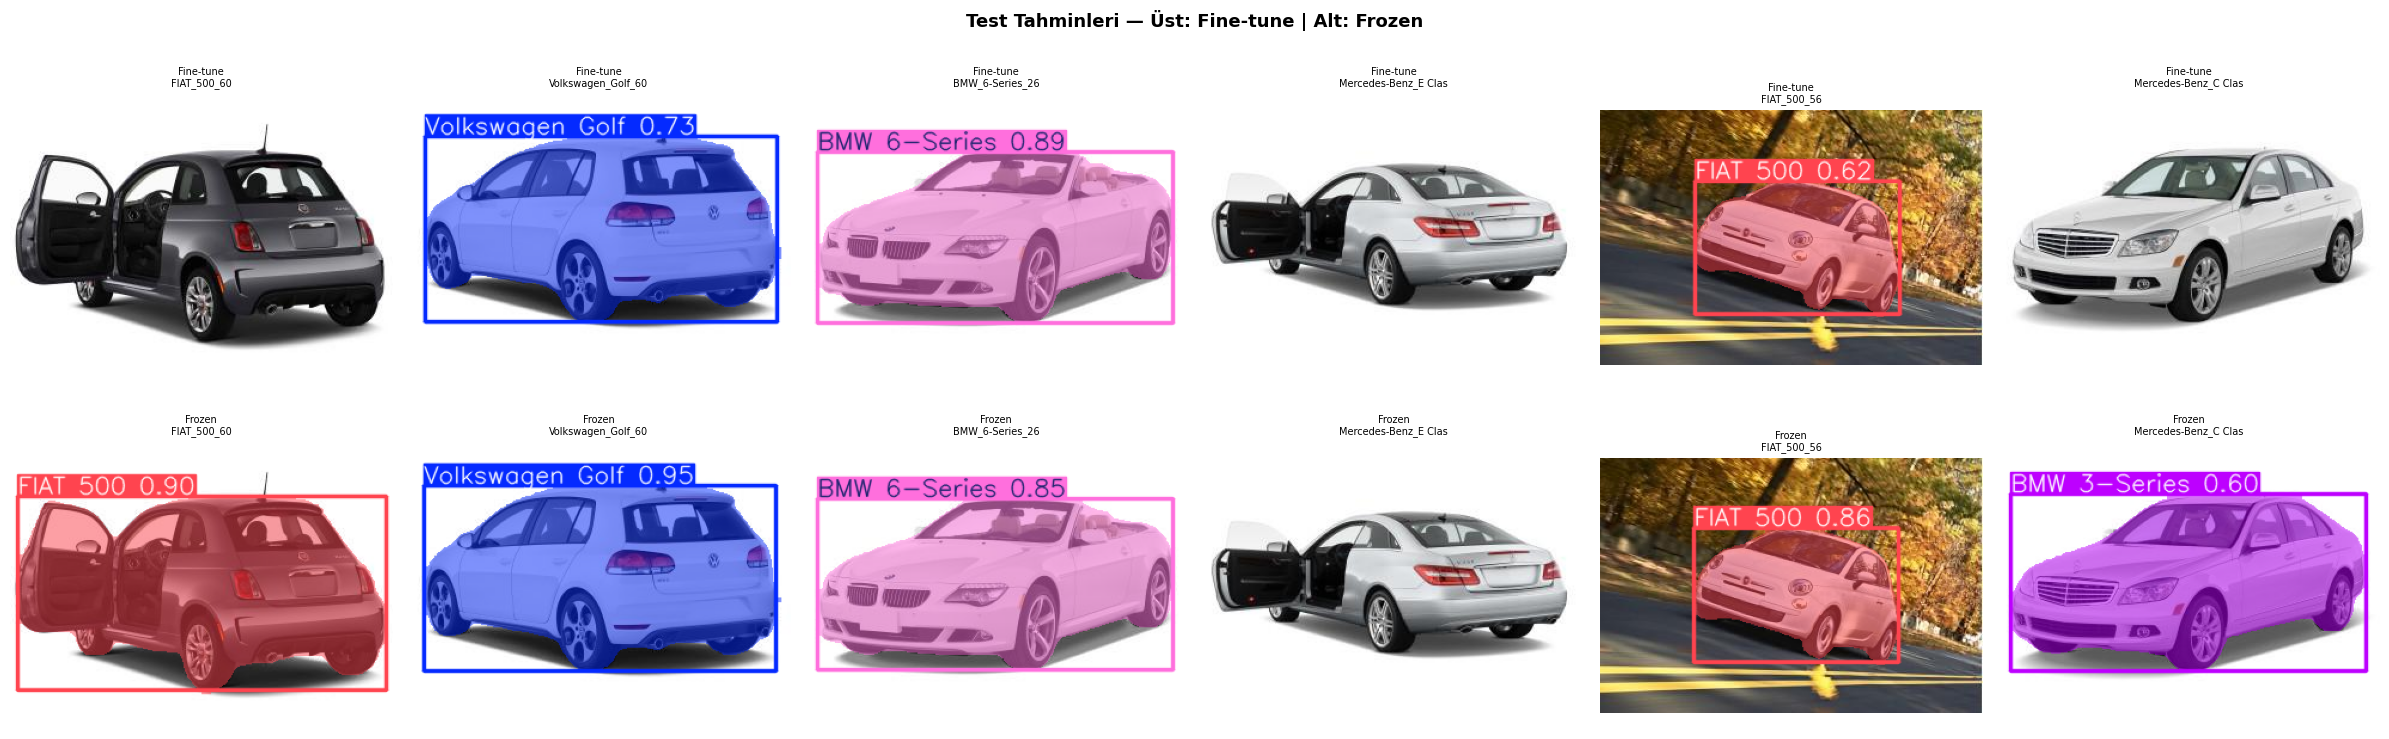


Tüm çıktılar: /content/adas_model_projesi


In [10]:
import cv2
from pathlib import Path

test_images = list(Path(f"{base_dir}/test/images").glob("*.jpg"))
samples     = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for col, img_path in enumerate(samples):
    for row, (model_obj, label) in enumerate([(model1, "Fine-tune"), (model2, "Frozen")]):
        result    = model_obj.predict(str(img_path), imgsz=IMGSZ, conf=0.4,
                                      device=device, verbose=False)[0]
        annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(annotated)
        axes[row][col].set_title(f"{label}\n{img_path.stem[:20]}", fontsize=7)
        axes[row][col].axis('off')

plt.suptitle("Test Tahminleri — Üst: Fine-tune | Alt: Frozen", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik4_tahminler.png", dpi=150)
plt.show()
print("\nTüm çıktılar:", base_dir)

Threshold analizi başlıyor...
  Conf |   FT mAP50 |   FR mAP50 |   FT Prec |   FR Prec |   FT Rec |   FR Rec
---------------------------------------------------------------------------
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 315.6±204.4 MB/s, size: 10.0 KB)
val: Scanning /content/adas_model_projesi/test/labels.cache... 396 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 396/396 110.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 6.4it/s 7.8s
                   all        396        418      0.547      0.539       0.51      0.506      0.547      0.539       0.51      0.505
Speed: 0.7ms preprocess, 10.6ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/segment/val-3
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 1

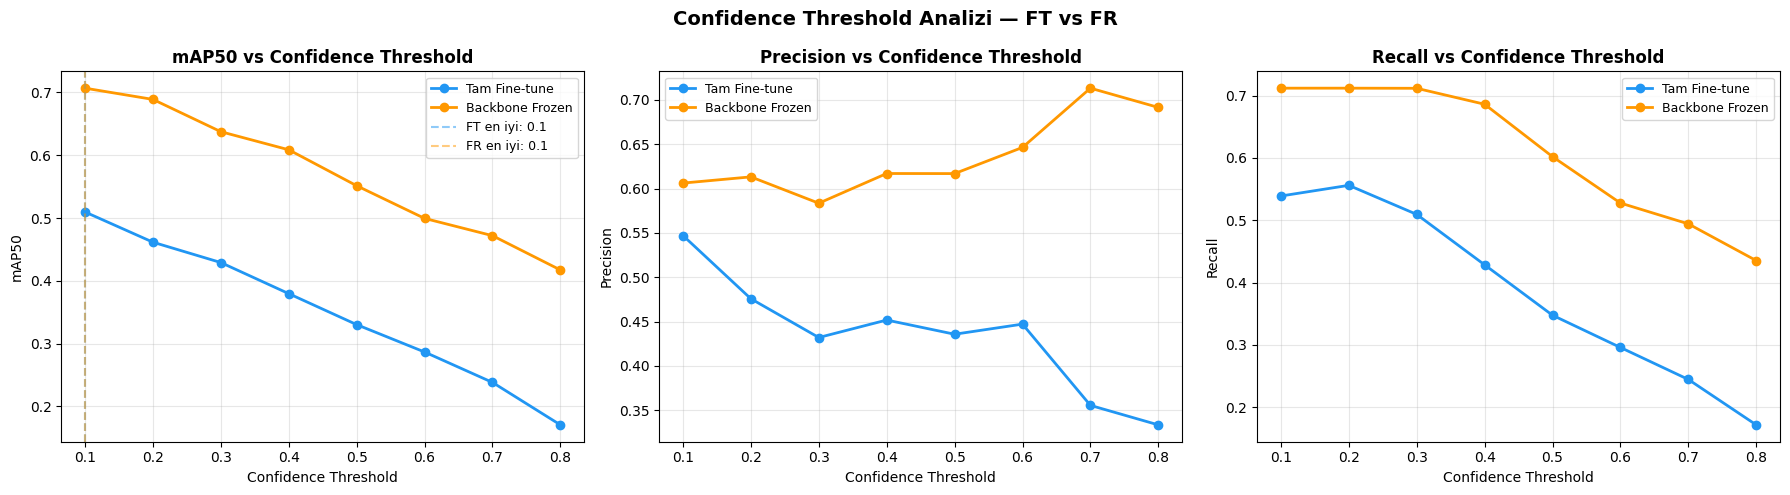

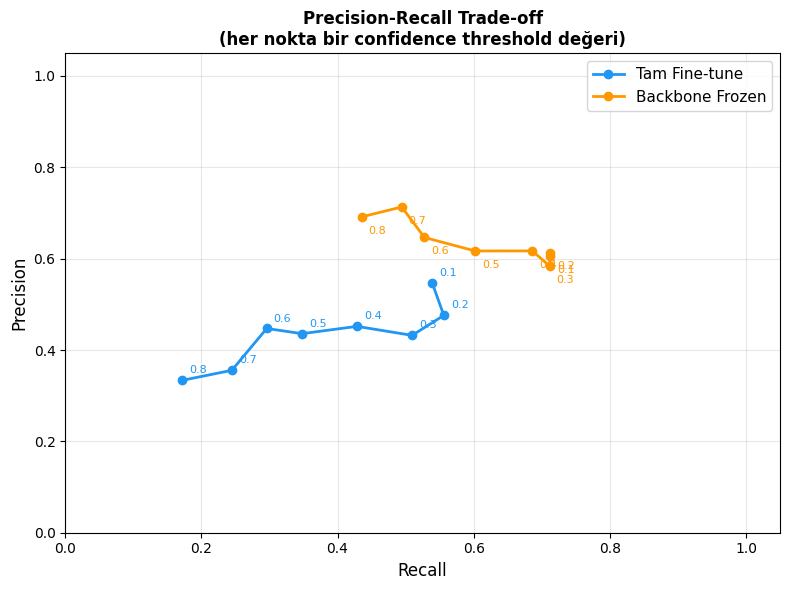


En iyi threshold → Fine-tune : 0.1  (mAP50=0.5096)
En iyi threshold → Frozen    : 0.1  (mAP50=0.7067)


In [11]:
# ============================================================
# HÜCRE 11 — Confidence Threshold Analizi
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else 'cpu'

try:
    model1
    model2
except NameError:
    model1 = YOLO(f"{base_dir}/deney1_fulltune/weights/best.pt")
    model2 = YOLO(f"{base_dir}/deney2_frozen/weights/best.pt")

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results_ft = {"conf": [], "mAP50": [], "mAP50_95": [], "Precision": [], "Recall": []}
results_fr = {"conf": [], "mAP50": [], "mAP50_95": [], "Precision": [], "Recall": []}

print("Threshold analizi başlıyor...")
print(f"{'Conf':>6} | {'FT mAP50':>10} | {'FR mAP50':>10} | {'FT Prec':>9} | {'FR Prec':>9} | {'FT Rec':>8} | {'FR Rec':>8}")
print("-" * 75)

for conf in thresholds:
    m_ft = model1.val(data=f"{base_dir}/data.yaml", split='test',
                      imgsz=IMGSZ, batch=BATCH, conf=conf, device=device, verbose=False)
    m_fr = model2.val(data=f"{base_dir}/data.yaml", split='test',
                      imgsz=IMGSZ, batch=BATCH, conf=conf, device=device, verbose=False)

    ft_map50 = round(float(m_ft.seg.map50), 4)
    fr_map50 = round(float(m_fr.seg.map50), 4)
    ft_prec  = round(float(m_ft.seg.mp),    4)
    fr_prec  = round(float(m_fr.seg.mp),    4)
    ft_rec   = round(float(m_ft.seg.mr),    4)
    fr_rec   = round(float(m_fr.seg.mr),    4)

    results_ft["conf"].append(conf);      results_fr["conf"].append(conf)
    results_ft["mAP50"].append(ft_map50); results_fr["mAP50"].append(fr_map50)
    results_ft["mAP50_95"].append(round(float(m_ft.seg.map), 4))
    results_fr["mAP50_95"].append(round(float(m_fr.seg.map), 4))
    results_ft["Precision"].append(ft_prec); results_fr["Precision"].append(fr_prec)
    results_ft["Recall"].append(ft_rec);     results_fr["Recall"].append(fr_rec)

    print(f"{conf:>6.1f} | {ft_map50:>10.4f} | {fr_map50:>10.4f} | {ft_prec:>9.4f} | {fr_prec:>9.4f} | {ft_rec:>8.4f} | {fr_rec:>8.4f}")

best_ft_idx = results_ft["mAP50"].index(max(results_ft["mAP50"]))
best_fr_idx = results_fr["mAP50"].index(max(results_fr["mAP50"]))
best_ft_conf = results_ft["conf"][best_ft_idx]
best_fr_conf = results_fr["conf"][best_fr_idx]

# ── Grafik 1: mAP50 / Precision / Recall vs Threshold ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes,
                              ["mAP50", "Precision", "Recall"],
                              ["mAP50", "Precision", "Recall"]):
    ax.plot(thresholds, results_ft[metric], 'o-', color='#2196F3', linewidth=2, label='Tam Fine-tune')
    ax.plot(thresholds, results_fr[metric], 'o-', color='#FF9800', linewidth=2, label='Backbone Frozen')
    ax.set_title(f'{title} vs Confidence Threshold', fontsize=12, fontweight='bold')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].axvline(best_ft_conf, color='#2196F3', linestyle='--', alpha=0.5, label=f'FT en iyi: {best_ft_conf}')
axes[0].axvline(best_fr_conf, color='#FF9800', linestyle='--', alpha=0.5, label=f'FR en iyi: {best_fr_conf}')
axes[0].legend(fontsize=9)

plt.suptitle('Confidence Threshold Analizi — FT vs FR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik5_conf_threshold.png", dpi=150)
plt.show()

# ── Grafik 2: Precision-Recall Trade-off ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(results_ft["Recall"], results_ft["Precision"], 'o-', color='#2196F3', linewidth=2, label='Tam Fine-tune')
ax.plot(results_fr["Recall"], results_fr["Precision"], 'o-', color='#FF9800', linewidth=2, label='Backbone Frozen')

for i, conf in enumerate(thresholds):
    ax.annotate(f'{conf}', (results_ft["Recall"][i], results_ft["Precision"][i]),
                textcoords="offset points", xytext=(5, 5),   fontsize=8, color='#2196F3')
    ax.annotate(f'{conf}', (results_fr["Recall"][i], results_fr["Precision"][i]),
                textcoords="offset points", xytext=(5, -12), fontsize=8, color='#FF9800')

ax.set_title('Precision-Recall Trade-off\n(her nokta bir confidence threshold değeri)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik6_pr_tradeoff.png", dpi=150)
plt.show()

# ── CSV kaydet ────────────────────────────────────────────────
df_ft = pd.DataFrame(results_ft)
df_fr = pd.DataFrame(results_fr).drop(columns="conf")
df_combined = pd.concat([df_ft, df_fr.add_suffix('_FR')], axis=1)
df_combined.to_csv(f"{base_dir}/conf_threshold_analizi.csv", index=False)

print(f"\nEn iyi threshold → Fine-tune : {best_ft_conf}  (mAP50={results_ft['mAP50'][best_ft_idx]})")
print(f"En iyi threshold → Frozen    : {best_fr_conf}  (mAP50={results_fr['mAP50'][best_fr_idx]})")


VERİ MİKTARI: Sınıf başı 30 resim
  Train:504  Valid:101  Test:99

  [FT] Eğitim başlıyor...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/adas_model_projesi/lc_30/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0,

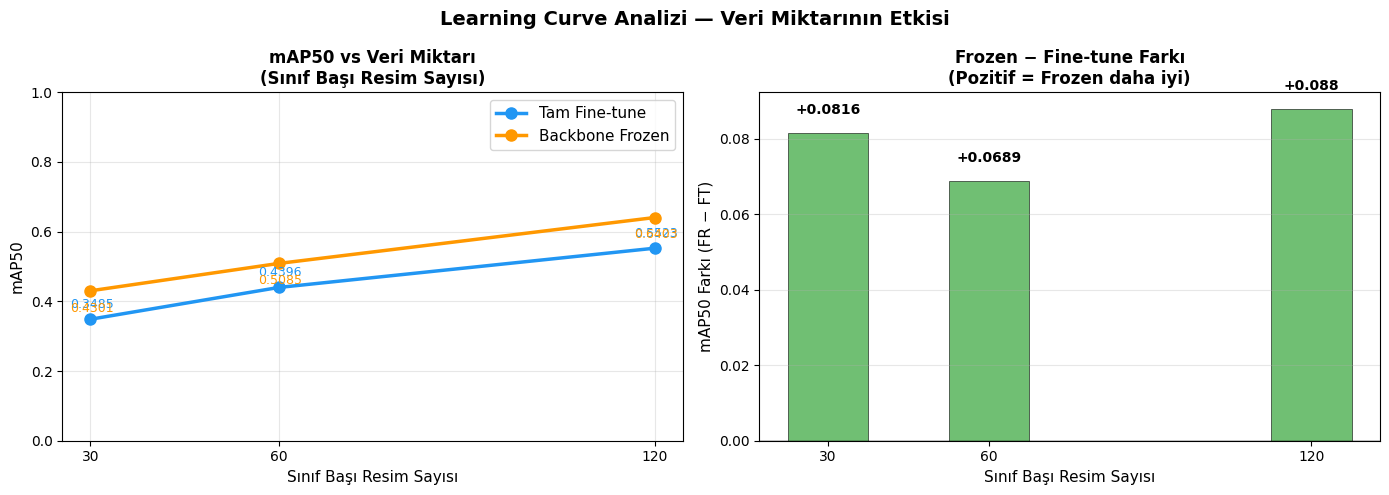


Grafik 7 kaydedildi.

Sonuç: Veri arttıkça fark kapanmıyor → Frozen üstünlüğünü koruyor.


In [12]:
# ============================================================
# HÜCRE 12 — Learning Curve: Veri Miktarı Etkisi
# ============================================================
import os, shutil, random, gc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO

device    = 0 if torch.cuda.is_available() else 'cpu'
VER_MIKT  = [30, 60, 120]   # 120 zaten var ama tekrar eğitip tutarlılık sağlıyoruz
EPOCHS_LC = 15              # Hız için 15 epoch yeterli
lc_results = []             # Sonuçları burada toplayacağız

for n in VER_MIKT:
    print(f"\n{'='*55}")
    print(f"VERİ MİKTARI: Sınıf başı {n} resim")
    print(f"{'='*55}")

    # ── Alt veri seti klasörünü oluştur ───────────────────────
    lc_dir = f"{base_dir}/lc_{n}"
    for split in ['train', 'valid', 'test']:
        os.makedirs(f"{lc_dir}/{split}/images", exist_ok=True)
        os.makedirs(f"{lc_dir}/{split}/labels", exist_ok=True)

    # Orijinal train/valid/test'ten n resim al (sınıf başı)
    for split in ['train', 'valid', 'test']:
        src_img = f"{base_dir}/{split}/images"
        src_lbl = f"{base_dir}/{split}/labels"

        # Sınıf başı dosyaları grupla
        class_files = {}
        for fname in os.listdir(src_img):
            if not fname.endswith('.jpg'): continue
            parts    = fname.split('_')
            cls_name = f"{parts[0]}_{parts[1]}"
            class_files.setdefault(cls_name, []).append(fname)

        # Her sınıftan oransal al
        # train:%70, valid:%15, test:%15 → train'den n*0.7, valid'den n*0.15 al
        ratio = {'train': 0.70, 'valid': 0.15, 'test': 0.15}
        take  = max(1, int(n * ratio[split]))

        for cls_name, files in class_files.items():
            chosen = random.sample(files, min(take, len(files)))
            for fname in chosen:
                shutil.copy(f"{src_img}/{fname}", f"{lc_dir}/{split}/images/{fname}")
                lbl = fname.replace('.jpg', '.txt')
                if os.path.exists(f"{src_lbl}/{lbl}"):
                    shutil.copy(f"{src_lbl}/{lbl}", f"{lc_dir}/{split}/labels/{lbl}")

    # data.yaml
    import yaml
    lc_yaml = {
        'path' : lc_dir,
        'train': 'train/images',
        'val'  : 'valid/images',
        'test' : 'test/images',
        'nc'   : len(class_map),
        'names': [nm.replace('_', ' ') for nm in top_models]
    }
    with open(f"{lc_dir}/data.yaml", 'w') as f:
        yaml.dump(lc_yaml, f, allow_unicode=True)

    train_n = len(os.listdir(f"{lc_dir}/train/images"))
    valid_n = len(os.listdir(f"{lc_dir}/valid/images"))
    test_n  = len(os.listdir(f"{lc_dir}/test/images"))
    print(f"  Train:{train_n}  Valid:{valid_n}  Test:{test_n}")

    # ── FT Eğitimi ────────────────────────────────────────────
    print(f"\n  [FT] Eğitim başlıyor...")
    m_ft = YOLO('yolov8m-seg.pt')
    m_ft.train(
        data=f"{lc_dir}/data.yaml", epochs=EPOCHS_LC,
        imgsz=IMGSZ, batch=BATCH, patience=5,
        device=device, project=lc_dir, name='ft',
        exist_ok=True, freeze=None, optimizer='AdamW',
        lr0=0.001, lrf=0.01, mosaic=0.5, mixup=0.0,
        verbose=False,
    )
    val_ft = YOLO(f"{lc_dir}/ft/weights/best.pt").val(
        data=f"{lc_dir}/data.yaml", split='test',
        imgsz=IMGSZ, batch=BATCH, device=device, verbose=False
    )
    map_ft = round(float(val_ft.seg.map50), 4)
    del m_ft; gc.collect(); torch.cuda.empty_cache()
    print(f"  [FT] mAP50 = {map_ft}")

    # ── Frozen Eğitimi ────────────────────────────────────────
    print(f"\n  [FR] Eğitim başlıyor...")
    m_fr = YOLO('yolov8m-seg.pt')
    m_fr.train(
        data=f"{lc_dir}/data.yaml", epochs=EPOCHS_LC,
        imgsz=IMGSZ, batch=BATCH, patience=5,
        device=device, project=lc_dir, name='fr',
        exist_ok=True, freeze=10, optimizer='AdamW',
        lr0=0.001, lrf=0.01, mosaic=0.5, mixup=0.0,
        verbose=False,
    )
    val_fr = YOLO(f"{lc_dir}/fr/weights/best.pt").val(
        data=f"{lc_dir}/data.yaml", split='test',
        imgsz=IMGSZ, batch=BATCH, device=device, verbose=False
    )
    map_fr = round(float(val_fr.seg.map50), 4)
    del m_fr; gc.collect(); torch.cuda.empty_cache()
    print(f"  [FR] mAP50 = {map_fr}")

    lc_results.append({"n": n, "FT": map_ft, "FR": map_fr, "fark": round(map_fr - map_ft, 4)})
    print(f"\n  Özet → FT:{map_ft}  FR:{map_fr}  Fark:{round(map_fr-map_ft,4)}")

# ── Sonuç tablosu ─────────────────────────────────────────────
df_lc = pd.DataFrame(lc_results)
print("\n" + "="*45)
print("LEARNING CURVE SONUÇLARI")
print("="*45)
print(df_lc.to_string(index=False))
print("="*45)
df_lc.to_csv(f"{base_dir}/learning_curve.csv", index=False)

# ── Grafik 1: mAP50 vs Veri Miktarı ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_lc["n"], df_lc["FT"], 'o-', color='#2196F3',
             linewidth=2.5, markersize=8, label='Tam Fine-tune')
axes[0].plot(df_lc["n"], df_lc["FR"], 'o-', color='#FF9800',
             linewidth=2.5, markersize=8, label='Backbone Frozen')

for _, row in df_lc.iterrows():
    axes[0].annotate(f'{row["FT"]}', (row["n"], row["FT"]),
                     textcoords="offset points", xytext=(-15, 8), fontsize=9, color='#2196F3')
    axes[0].annotate(f'{row["FR"]}', (row["n"], row["FR"]),
                     textcoords="offset points", xytext=(-15, -15), fontsize=9, color='#FF9800')

axes[0].set_title('mAP50 vs Veri Miktarı\n(Sınıf Başı Resim Sayısı)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sınıf Başı Resim Sayısı', fontsize=11)
axes[0].set_ylabel('mAP50', fontsize=11)
axes[0].set_xticks(df_lc["n"])
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# ── Grafik 2: Fark (FR - FT) vs Veri Miktarı ─────────────────
axes[1].bar(df_lc["n"], df_lc["fark"], width=15,
            color=['#4CAF50' if x > 0 else '#F44336' for x in df_lc["fark"]],
            alpha=0.8, edgecolor='black', linewidth=0.5)

for _, row in df_lc.iterrows():
    axes[1].text(row["n"], row["fark"] + 0.005, f'+{row["fark"]}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Frozen − Fine-tune Farkı\n(Pozitif = Frozen daha iyi)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sınıf Başı Resim Sayısı', fontsize=11)
axes[1].set_ylabel('mAP50 Farkı (FR − FT)', fontsize=11)
axes[1].set_xticks(df_lc["n"])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Learning Curve Analizi — Veri Miktarının Etkisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_dir}/grafik7_learning_curve.png", dpi=150)
plt.show()
print("\nGrafik 7 kaydedildi.")
print(f"\nSonuç: Veri arttıkça fark {'daralıyor' if df_lc['fark'].is_monotonic_decreasing else 'kapanmıyor'} → Frozen {'avantajını kaybediyor' if df_lc['fark'].is_monotonic_decreasing else 'üstünlüğünü koruyor'}.")

In [13]:
# Colab'da çalıştır — tüm grafikleri listele
import os
grafik_listesi = []
for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith('.png'):
            grafik_listesi.append(os.path.join(root, f))

for g in sorted(grafik_listesi):
    print(g)

/content/adas_model_projesi/deney1_fulltune/BoxF1_curve.png
/content/adas_model_projesi/deney1_fulltune/BoxPR_curve.png
/content/adas_model_projesi/deney1_fulltune/BoxP_curve.png
/content/adas_model_projesi/deney1_fulltune/BoxR_curve.png
/content/adas_model_projesi/deney1_fulltune/MaskF1_curve.png
/content/adas_model_projesi/deney1_fulltune/MaskPR_curve.png
/content/adas_model_projesi/deney1_fulltune/MaskP_curve.png
/content/adas_model_projesi/deney1_fulltune/MaskR_curve.png
/content/adas_model_projesi/deney1_fulltune/confusion_matrix.png
/content/adas_model_projesi/deney1_fulltune/confusion_matrix_normalized.png
/content/adas_model_projesi/deney1_fulltune/results.png
/content/adas_model_projesi/deney2_frozen/BoxF1_curve.png
/content/adas_model_projesi/deney2_frozen/BoxPR_curve.png
/content/adas_model_projesi/deney2_frozen/BoxP_curve.png
/content/adas_model_projesi/deney2_frozen/BoxR_curve.png
/content/adas_model_projesi/deney2_frozen/MaskF1_curve.png
/content/adas_model_projesi/deney2

In [14]:
import shutil
grafik_listesi = [
    f"{base_dir}/grafik1_metrik_karsilastirma.png",
    f"{base_dir}/grafik2_loss_curves.png",
    f"{base_dir}/grafik3_map50_curve.png",
    f"{base_dir}/grafik5_conf_threshold.png",
    f"{base_dir}/grafik6_pr_tradeoff.png",
    f"{base_dir}/grafik7_learning_curve.png",
    f"{base_dir}/deney1_fulltune/results.png",
    f"{base_dir}/deney2_frozen/results.png",
    f"{base_dir}/deney1_fulltune/confusion_matrix_normalized.png",
    f"{base_dir}/deney2_frozen/confusion_matrix_normalized.png",
]

import os
os.makedirs("/content/rapor_grafikleri", exist_ok=True)
for g in grafik_listesi:
    shutil.copy(g, "/content/rapor_grafikleri/")

shutil.make_archive("/content/rapor_grafikleri", "zip", "/content/rapor_grafikleri")
print("İndir: /content/rapor_grafikleri.zip")

İndir: /content/rapor_grafikleri.zip
